# **RETAIR STORE SALES**

# **Import Library**

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# **CHECKPOINT 1**

## **Bussiness Understanding**

### **Business Objective**

<div align= "justify">
Permasalahan bisnis yang diidentifikasi adalah perlunya perusahaan memahami pola penjualan dan perilaku pelanggan dari data transaksi toko. Data ini menunjukkan variasi pembelian berdasarkan kategori produk, musim, metode pembayaran, rating produk serta mengenali pelanggan yang berpotensi melakukan pembelian ulang.

Bertujuan untuk memahami masalah utama yang dihadapi toko, yaitu bagaimana pola belanja pelanggan daat digunakan untuk meningkatkan penjualan dan layanan.

Masalah utama adalah toko perlu
meningkatkan pendapatan, menentukan produk terlaris, mengoptimalkan diskon, membuat stratgei promosi yang lebih tepat, dan meningkatkan kepuasan pelanggan berdasarkan rating transaksi.
</div>

### **Assess Situation**

<div align= "justify">
Dataset berisi informasi kategori produk, jumlah pembelian, diskon, musim, metode pembayaran, rating produk, dan riwayat pembeli sebelumnya. Data sudah cukup untuk menganalisis pola penjualan dan perilaku pelanggan secara umum, tetapi memliki keterbatasan karena tidak terdapat data tanggal transaksi, serta profit atau harga asli produk. Selain itu, kategori produk masih bersifat umum dan rating tidak disertai ulasan, sehingga analisis yang dilakukan terbatas pada gambaran umum dan tidak dapat diketahui secara berkelanjutan.
</d>

### **Analytic Goals**

<div align= "justify">
Analisis dilakukan dengan melihat kategori produk yang paling laku, mengecek apakah diskon dapat meningkatkan pembelian, memahami pola tren berdasarkan musim, serta menilai kepuasan pelanggan lewat rating produk. Riwayat pembelian juga digunakan untuk mengenali pelanggan yang sering membeli agar strategi pemasaran bisa lebih tepat.
</div>

### **Project Plans**

1. Business Understanding
Tujuan utama adalah memahami pola pembelian pelanggan dan mengidentifikasi faktor yang memengaruhi besarnya transaksi. Fokus pada Amount sebagai indikator utama performa penjualan.

2. Data Understanding
Identifikasi tipe data dan struktur dataset. Kolom utama yang dianalisis adalah Amount, Category, Season, Gender, DiscountApplied(%), ItemRating, dan PreviousPurchases. Lakukan pengecekan duplikasi, missing values, dan outliers pada kolom numerik.

3. Data Preparation
Bersihkan data dari duplikasi. Tangani outliers pada Amount jika diperlukan sesuai tujuan analisis. Pastikan tipe data sudah sesuai. Siapkan data agregasi untuk analisis per kategori dan per musim.

4. Exploratory Data Analysis
Lakukan empat pilar analisis:
Comparison. Bandingkan total Amount per Category dan Season.
Composition. Hitung persentase kontribusi 3 kategori dengan Amount tertinggi.
Distribution. Analisis distribusi Amount menggunakan histogram.
Relationship. Analisis korelasi antara DiscountApplied(%), Amount, dan PreviousPurchases menggunakan heatmap.

5. Insight Generation
Identifikasi kategori dengan kontribusi terbesar.
Analisis pola pembelian berdasarkan musim dan gender.
Evaluasi efektivitas diskon terhadap nilai transaksi.
Tentukan apakah pelanggan dengan pembelian sebelumnya tinggi cenderung bertransaksi lebih besar.

6. Recommendation
Fokuskan strategi promosi pada kategori dengan kontribusi tinggi.
Optimalkan kategori menengah untuk meningkatkan keseimbangan pendapatan.
Evaluasi ulang strategi diskon jika tidak berpengaruh signifikan terhadap Amount.
Gunakan data PreviousPurchases untuk strategi loyalitas pelanggan.

7. Optional Model Development
Bangun model regresi sederhana untuk memprediksi Amount berdasarkan DiscountApplied(%), PreviousPurchases, dan ItemRating jika dibutuhkan untuk analisis lanjutan.

# **CHECKPOINT 2**

## **Data Understanding**

### **Memuat Dataset**

In [44]:
path = "/content/drive/MyDrive/Google Collab AVD/store_sales.csv"
df = pd.read_csv(path)

In [45]:
df

,CustomerID,Age,Gender,Category,ItemPurchased,Amount,Season,PaymentMethod,ItemRating,DiscountApplied(%),PreviousPurchases
0,1,58,Female,Accessories,Handbag,115.50,Autumn,Card,3.5,18,4
1,2,40,Male,Mens Clothing,Shirt,103.43,Spring,Card,4.1,13,4
2,3,66,Female,Sports,Football,35.45,Spring,Card,3.3,11,3
3,4,39,Female,Accessories,Handbag,153.31,Spring,Card,4.4,13,4
4,5,23,Female,Home,Curtains,151.43,Winter,Card,4.1,20,10
...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,44,Female,Accessories,Sunglasses,172.64,Winter,Card,3.6,20,5
4996,4997,59,Male,Groceries,Beverages,54.00,Spring,Cash on Delivery,3.8,14,2
4997,4998,41,Female,Accessories,Handbag,159.33,Autumn,Card,4.3,26,8
4998,4999,63,Female,Womens Clothing,Skirt,173.82,Autumn,Card,4.8,26,8


### **Deskripsi Data**

#### **Informasi Dasar**

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CustomerID          5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Gender              5000 non-null   object 
 3   Category            5000 non-null   object 
 4   ItemPurchased       5000 non-null   object 
 5   Amount              5000 non-null   float64
 6   Season              5000 non-null   object 
 7   PaymentMethod       5000 non-null   object 
 8   ItemRating          5000 non-null   float64
 9   DiscountApplied(%)  5000 non-null   int64  
 10  PreviousPurchases   5000 non-null   int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 429.8+ KB


Berdasarkan data di atas, dapat diketahui dataset ini memiliki 5.000 baris dan 11 kolom.

#### **Informasi Lanjutan**

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CustomerID          5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Gender              5000 non-null   object 
 3   Category            5000 non-null   object 
 4   ItemPurchased       5000 non-null   object 
 5   Amount              5000 non-null   float64
 6   Season              5000 non-null   object 
 7   PaymentMethod       5000 non-null   object 
 8   ItemRating          5000 non-null   float64
 9   DiscountApplied(%)  5000 non-null   int64  
 10  PreviousPurchases   5000 non-null   int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 429.8+ KB


1. CustomerID: 0
- Jumlah baris: 5000
- Tipe data: int64
- Deskripsi: ID kostumer

2. Age: 1
- Jumlah baris: 5000
- Tipe data: int64
- Deskrpsi: Umur

3. Gender: 2
- Jumlah baris: 5000
- Tipe data: object
- Deskripsi: Jenis kelamin

4. Category: 3
- Jumlah baris: 5000
- Tipe data: object
- Deskripsi: Kategori

5. ItemPurchased: 4
- Jumlah baris: 5000
- Tipe data: object
- Deskripsi: Barang yang dibeli

6. Amount: 5
- Jumlah baris: 5000
- Tipe data: float64
- Deskripsi: Jumlah

7. Season: 6
- Jumlah baris: 5000
- Tipe data: object
- Deskripsi: Musim

8. PaymentMethod: 7
- Jumlah baris: 5000
- Tipe data: object
- Deskripsi: Metode Pembayaran

9. ItemRating: 8
- Jumlah baris: 5000
- Tipe data: float64
- Deskripsi: Peringkat Barang

10. DiscountApplied(&): 9
- Jumlah baris: 5000
- Tipe data: int64
- Deskripsi: Diskon yang diterapkan

11. PreviousPurchases
- Jumlah baris: 5000
- Tipe data: int64
- Deskripsi: Pembelian Sebelumnya

#### **Informasi Statistik Deskriptif**

In [48]:
df.describe(include="all")

,CustomerID,Age,Gender,Category,ItemPurchased,Amount,Season,PaymentMethod,ItemRating,DiscountApplied(%),PreviousPurchases
count,5000.000000,5000.000000,5000,5000,5000,5000.000000,5000,5000,5000.000000,5000.000000,5000.000000
unique,NaN,NaN,2,9,30,NaN,4,2,NaN,NaN,NaN
top,NaN,NaN,Female,Footwear,Sandals,NaN,Spring,Card,NaN,NaN,NaN
freq,NaN,NaN,2504,983,339,NaN,1300,4009,NaN,NaN,NaN
mean,2500.500000,45.224800,NaN,NaN,NaN,285.090522,NaN,NaN,3.784160,14.983600,5.008800
std,1443.520003,14.564995,NaN,NaN,NaN,551.454382,NaN,NaN,0.681796,5.988063,2.194285
min,1.000000,20.000000,NaN,NaN,NaN,5.080000,NaN,NaN,1.100000,0.000000,0.000000
25%,1250.750000,33.000000,NaN,NaN,NaN,70.547500,NaN,NaN,3.300000,11.000000,3.000000
50%,2500.500000,45.000000,NaN,NaN,NaN,122.485000,NaN,NaN,3.800000,15.000000,5.000000
75%,3750.250000,58.000000,NaN,NaN,NaN,184.535000,NaN,NaN,4.300000,19.000000,6.000000


1. Count (Kelengkapan Data)
Berdasarkan data, total baris transaksi adalah 5000 dan tidak terdapat missing value pada dataset.

---

2. Mean Vs Median (Distribusi Data)
* Kolom Amount
  * Mean = 285,09
  * Median = 122,49 - Nilai rata-rata lebih besar dari median

  menunjukkan adanya transaksi dengan nilai sangat tinggi yang menarik rata-rata ke atas.

* Kolom PreviousPurchases
  * Mean = 5,01
  * Median = 5,00 - Nilai hampir sama

  menunjukkan distribusi relatif simetris, tidak ada lonjakan ekstrem.

* Kolom ItemRating
  * Mean = 3,78
  * Median = 3,80 - Nilai hampir sama

  menunjukkan distribusi stabil dan cukup konsisten di sekitar 3 sampai 4.

* Kolom DiscountApplied(&)
  * Mean = 14,98
  * Median = 15,00 - Nilai hampir sama

  menandakan diskon rata-rata stabil di sekitar 15 persen, variabel relatif stabil dan mendekati distribusi normal.

Kesimpulan: Variabel amount bersifat right skewed (condong ke kanan), sedangkan variabel lain relatif stabil dan mendekati distribusi normal.

---

3. Min dan Max (Validasi Logika)

* Amount
  * Min = 5,08
  * Max = 2.997,94

* PreviousPurchases
  * Min = 0
  * Max = 13

* ItemRating
  * Min = 1,1
  * Max = 5,0

* DiscountApplied
  * Min = 0
  * Max = 36

  Kesimpulan: Tidak ada nilai yang terlihat sebagai kesalahan input, namun transaksi Amount mendekati 3.000 perlu dianalisis lebih lanjut.

  ---

4. Standar Deviasi (std) - Variabilitas Data
* Amount
  * Mean = 285,09
  * Std = 551,45

* PreviousPurchases
  * Mean = 5,01
  * Std = 2,19

* ItemRating
  * Mean = 3,78
  * Std = 0,68

* DiscountApplied
  * Mean = 14,98
  * Std = 5,99

  Kesimpulan: Variabel Amount memiliki varibilitas paling tinggi dan menjadi faktor utama yang memengaruhi distribusi data. Variabel lain relatif stbail dan konsisten.
  

### **Verifikasi Kualitas Data**

#### **Data Type Check**

<div align= "justify">
Kita akan mengecek tipe data dari setiap kolom apakah sudah sesuai atau tidak. Agar insight serta visualisasi yang akan kita buat menjadi akurat.
</dir>

In [49]:
df.dtypes

,0
CustomerID,int64
Age,int64
Gender,object
Category,object
ItemPurchased,object
Amount,float64
Season,object
PaymentMethod,object
ItemRating,float64
DiscountApplied(%),int64


<div align= "justify">

- Kolom numerik seperti Age, Amount, ItemRating, DiscountApplied(%), dan PreviousPurchases sudah sesuai.

- Kolom kategorikal seperti Gender, Category, ItemPurchased, Season, dan PaymentMethod sudah sesuai sebagai object.

- CustomerID bertipe int64 secara teknis benar, tetapi secara analisis sebaiknya diperlukan dengan identifier, bukan variabel numerik untuk perhitungan statistik.
</div>

#### **Incosistent Values**

<div align= "justify">
Pada tahap ini, kita perlu mengecek kekonsistenan data, contoh nya dalam penulisan. Hal ini dilakukan agar data tidak terduplikat dengan baris yang sebenarnya sama akan tetapi bisa terduplikat karena tidak konsisten.

Alasan saya menggunakan Value_counts adalah sebagai bukti lebih lanjut terhadap dataset.
</dir>

1. Gender

  Pada kolom ini, dapat terlihat penyebutan gender konsisten dengan format yang sama.

In [50]:
print(df["Gender"].unique())

['Female' 'Male']


In [51]:
print(df["Gender"].value_counts())

Gender
Female    2504
Male      2496
Name: count, dtype: int64


2. Category

Pada kolom ini, dapat dilihat penyebutan category konsisten.

In [52]:
print(df['Category'].unique())

['Accessories' 'Mens Clothing' 'Sports' 'Home' 'Groceries' 'Electronics'
 'Beauty' 'Footwear' 'Womens Clothing']


In [53]:
print(df['Category'].value_counts())

Category
Footwear           983
Sports             835
Womens Clothing    547
Beauty             529
Mens Clothing      511
Electronics        507
Accessories        470
Groceries          332
Home               286
Name: count, dtype: int64


3. Item Purchased

Terdapat 30 item unik, tetap tidak ditemukannya huruf besar kecil atau typo (konsisten).

In [54]:
print(df['ItemPurchased'].unique())

['Handbag' 'Shirt' 'Football' 'Curtains' 'Snacks' 'Mobile Phone' 'Perfume'
 'Smart Watch' 'Formal Shoes' 'T-Shirt' 'Yoga Mat' 'Sandals' 'Dumbbells'
 'Sneakers' 'Jeans' 'Lamp' 'Skirt' 'Top' 'Dress' 'Rice Pack' 'Jacket'
 'Laptop' 'Sunglasses' 'Makeup Set' 'Kitchen Set' 'Headphones'
 'Cooking Oil' 'Skincare Kit' 'Wallet' 'Beverages']


In [55]:
print(df['ItemPurchased'].value_counts())

ItemPurchased
Sandals         339
Formal Shoes    324
Sneakers        320
Yoga Mat        283
Dumbbells       277
Football        275
Jeans           238
Skincare Kit    193
Makeup Set      176
Wallet          170
Perfume         160
Top             160
Handbag         152
Sunglasses      148
Laptop          142
Mobile Phone    140
Jacket          138
Skirt           136
T-Shirt         133
Shirt           130
Dress           123
Smart Watch     113
Headphones      112
Curtains         99
Lamp             98
Cooking Oil      93
Kitchen Set      89
Rice Pack        83
Snacks           79
Beverages        77
Name: count, dtype: int64


3. Payment Method

Pada kolom ini, tidak ada variasi seperti COD atau card (konsisten).

In [56]:
print(df['PaymentMethod'].unique())

['Card' 'Cash on Delivery']


In [57]:
print(df['PaymentMethod'].value_counts())

PaymentMethod
Card                4009
Cash on Delivery     991
Name: count, dtype: int64


4. Season

Tidak ada ditemukannya variasi huruf besar atau kecil (konsisten).

In [58]:
print(df['Season'].unique())

['Autumn' 'Spring' 'Winter' 'Summer']


In [59]:
print(df['Season'].value_counts())

Season
Spring    1300
Winter    1244
Autumn    1231
Summer    1225
Name: count, dtype: int64


Kesimpulan: Tidak ditemukan inconsistent values pada dataset, penulisan baris sudah seragam dan dataset aman dari masalah inkonsistensi penamaan.

#### **Duplicated Values**

Pada tahap ini, kita akan mengecek duplikasi pada dataset. Hal ini dilakukan agar dataset memiliki insight dan hasil yang bersih.

In [60]:
df[df.duplicated()]

,CustomerID,Age,Gender,Category,ItemPurchased,Amount,Season,PaymentMethod,ItemRating,DiscountApplied(%),PreviousPurchases


Dapat kita lihat pada dataset ini tidak ada duplikasi, maka hal ini tidak perlu ditangani.

#### **Outliers Values**

Pada tahap ini, kita mengecek nilai ekstrim (outliers) pada kolom numerik. Tujuannya agar analisis dan model yang dibangun tidak terdistorsi oleh nilai yang terlalu jauh dari mayoritas data. Nilai ekstrem bisa memengaruhi rata rata, korelasi, dan performa model.

Namun, tidak semua kolom perlu ditangani. Kita perlu memahami konteks bisnis dan fungsi setiap kolom yang ada di dataset.

Dapat dilihat kolom
* Amount

Dengan persentase 10%
* Previous Purchases

Dengan persentase 1%
* Discount Applied

Dengan persentase 0,44%
* Item Rating

Dengan persentase 0,18%

In [61]:
results = []

cols = df.select_dtypes(include=['float64', 'int64'])

for col in cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  percent_outliers = (len(outliers)/len(df))*100
  results.append({'Kolom': col, 'Persentase Outliers': percent_outliers})

# Dataframe dari list hasil
results_df = pd.DataFrame(results)
results_df.set_index('Kolom', inplace=True)
results_df = results_df.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)

# Tampilkan dataframe
display(results_df)

Kolom,Persentase Outliers
CustomerID,0.00
Age,0.00
Amount,10.14
ItemRating,0.18
DiscountApplied(%),0.44
PreviousPurchases,1.16


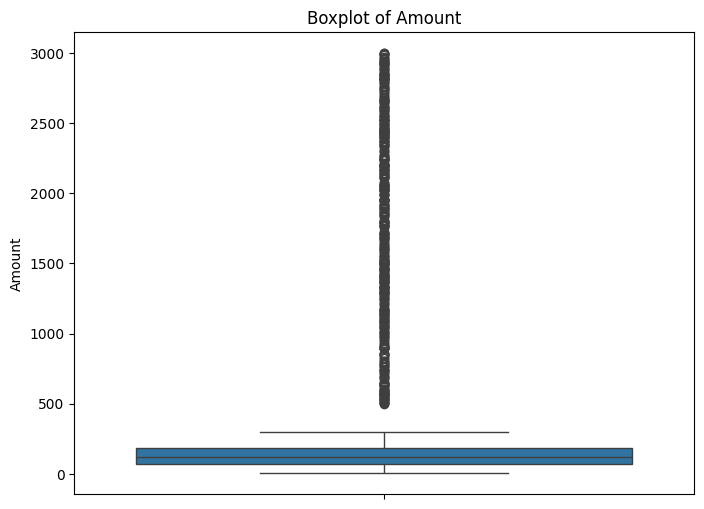

In [62]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Amount'])
plt.title('Boxplot of Amount')
plt.ylabel('Amount')
plt.show()

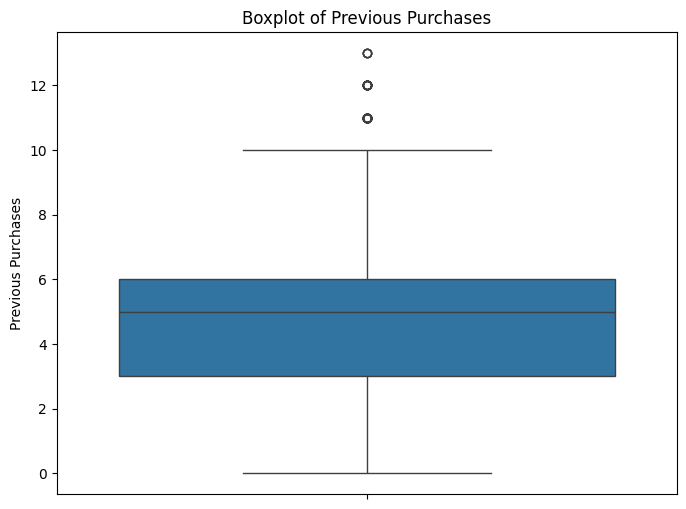

In [63]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['PreviousPurchases'])
plt.title('Boxplot of Previous Purchases')
plt.ylabel('Previous Purchases')
plt.show()

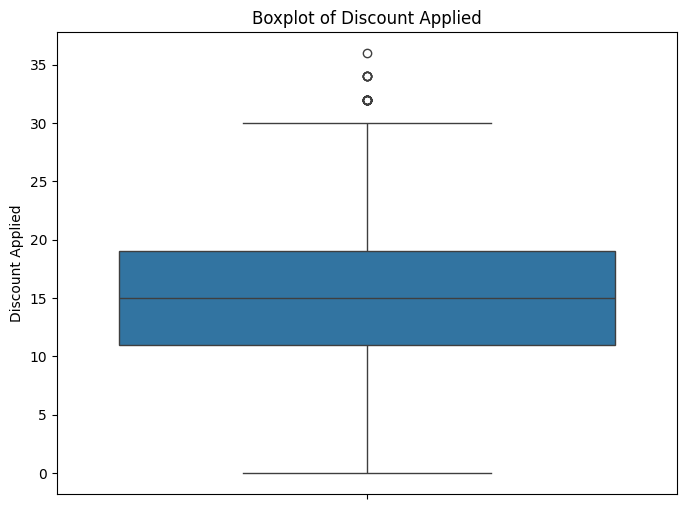

In [64]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['DiscountApplied(%)'])
plt.title('Boxplot of Discount Applied')
plt.ylabel('Discount Applied')
plt.show()

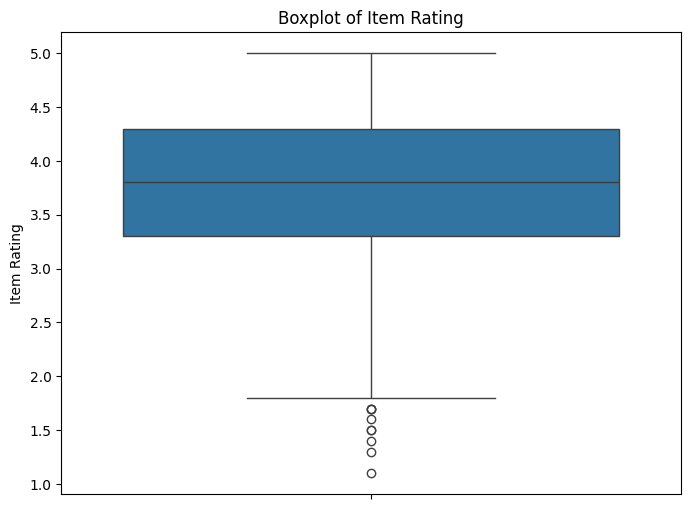

In [65]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['ItemRating'])
plt.title('Boxplot of Item Rating')
plt.ylabel('Item Rating')
plt.show()

## **Eksplorasi Data (EDA)**

### **Comparison/Perbandingan**

Aktivitas: Membandingkan total nominal pembelian pada setiap kategori

Tujuan: Mengidentifikasi kategori produk yang memberikan kontribusi pendapatan terbesar. Kita bisa melihat kategori mana yang paling banyak mengahsilkan uang dan kategori mana yang perlu ditingkatkan strateginya.

Visualisasi: Bar Chart (Grafik Batang).

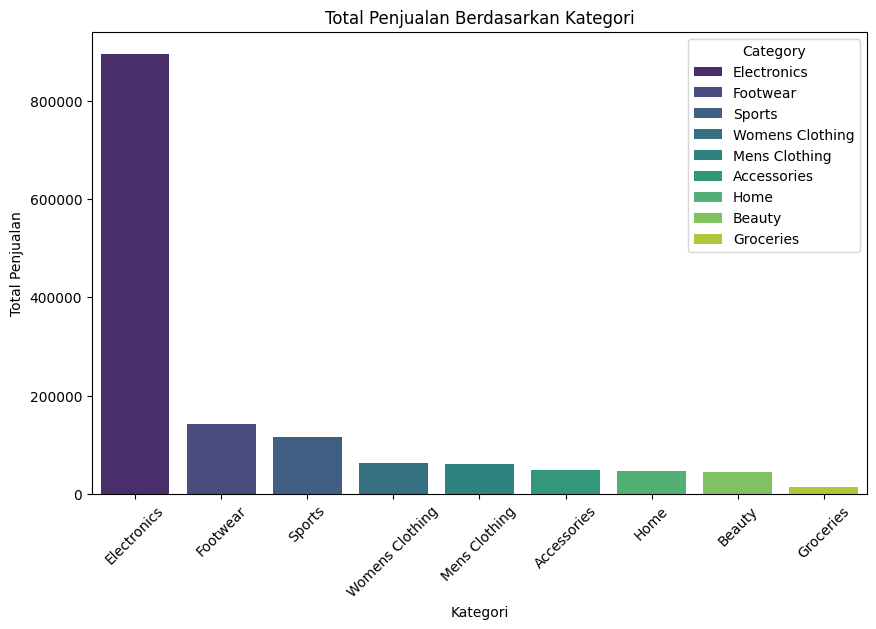

In [66]:
penjualan = df.groupby('Category')['Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=penjualan.index, y=penjualan.values, palette='viridis', hue= penjualan.index, legend=True)
plt.title('Total Penjualan Berdasarkan Kategori')
plt.xlabel('Kategori')
plt.ylabel('Total Penjualan')
plt.xticks(rotation=45)
plt.show()

Insight dari hasil perhitungan data, total Amount per Category menunjukkan:

- Electronics sekitar 895.402
- Footwear sekitar 141.142
- Sports sekitar 115.598
- Womens Clothing sekitar 61.718
- Mens Clothing sekitar 59.680
- Accessories sekitar 47.633
- Home sekitar 46.374
- Beauty sekitar 43.887
- Groceries sekitar 14.015

Hasil output dari visualisasi di atas menunjukkan bahwa kategori Electronics memberikan kontribusi pendapatan terbesar dan Groceries menjadi yang terendah. Kondisi ini menunjukkan peluang untuk mengembangkan kategori menengah agar lebih seimbang sekaligus mengurangi ketergantungan Electronics.

### **Composition/Komposisi**

Aktivitas: Menghitung persentase kontribusi total Amount pada setiap Category terhadap total keseluruhan penjualan

Tujuan: Mengetahui komposisi sumber pendapatan dan melihat kategori mana yang mendominasi serta kategori mana yang memiliki kontribusi kecil.

Visualisasi: Pie Chart (Grafik lingkaran)

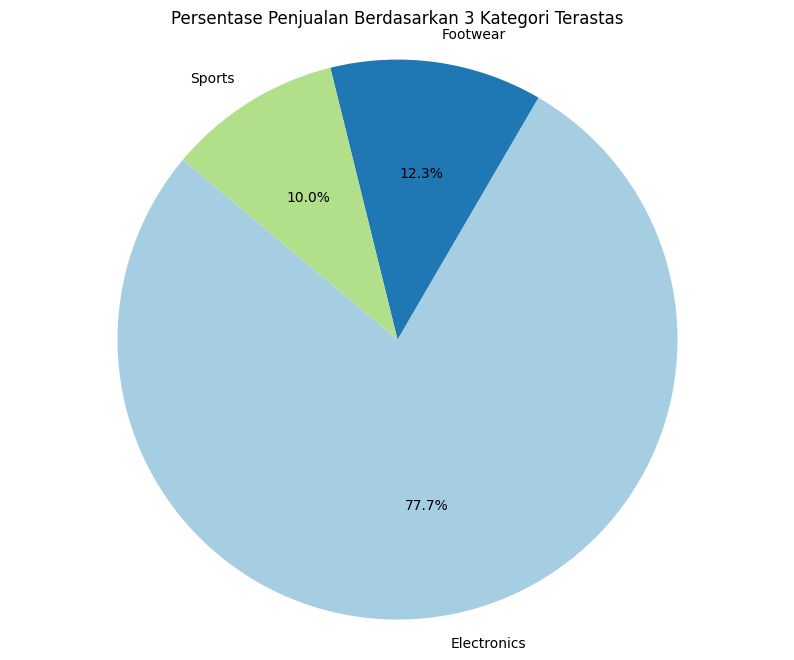

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

In [67]:
amount_by_category = df.groupby('Category')['Amount'].sum().sort_values(ascending=False)
amount_by_category_top3 = amount_by_category.head(3)

plt.figure(figsize=(10, 8))
amount_by_category_top3.plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Persentase Penjualan Berdasarkan 3 Kategori Terastas')
plt.ylabel('')
plt.axis('equal')
plt.show()
plt

Insight dari output visual di atas, menunjukkan total amount 3 kategori teratas berdasarkan kategori:

- Irisan Electronics 77,7%
- IrisanFootwear 12,3%
- Irisan Sports 10,0%

Pada pie chart, irisan Electronics paling dominan. Dua irisan lainnya lebih kecil tetapi tetap terlihat jelas sebagai kontributor penting.

### **Distribution/Distribusi**

Aktivitas: Menganalisis distribusi nilai Amount untuk melihat sebaran nominal transaksi pelanggan.

Tujuan: Memahami pola pembelian apakah mayoritas transaksi bernilai kecil, sedang, atau besar sehingga dapat mendukung strategi harga dan segmentasi pelanggan.

Visualisasi: Histogram

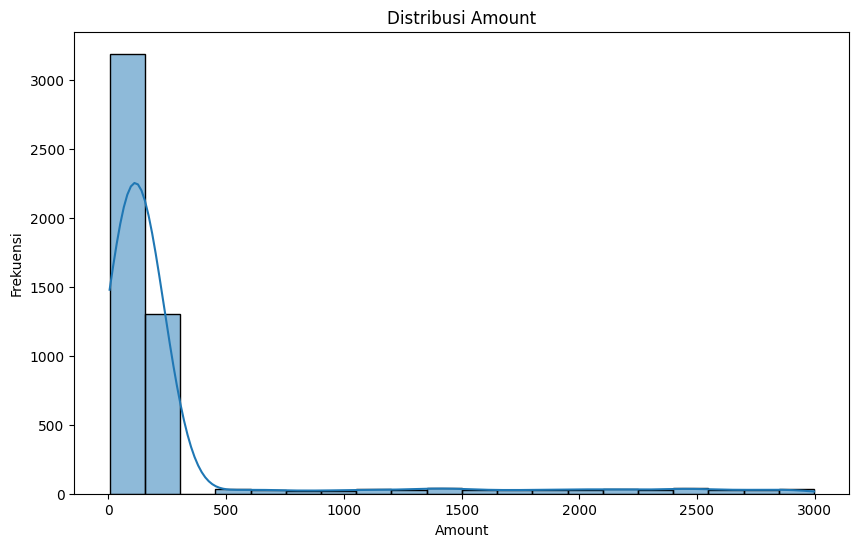

In [68]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Amount'], bins=20, kde=True)
plt.title('Distribusi Amount')
plt.xlabel('Amount')
plt.ylabel('Frekuensi')
plt.show()

Insight Distribution Amount

Distribusi Amount menunjukkan sebagian besar transaksi berada pada nilai rendah hingga sekitar 300. Frekuensi paling tinggi terlihat di rentang nominal kecil, kemudian menurun tajam seiring kenaikan nilai transaksi. Nilai di atas 500 hingga 3000 jumlahnya jauh lebih sedikit.

Pada histogram terlihat batang paling tinggi berada di sisi kiri grafik. Ini menandakan frekuensi transaksi kecil sangat dominan. Semakin ke kanan, batang semakin rendah dan jarang, membentuk pola miring ke kanan atau right skewed. Pola ini menunjukkan adanya beberapa transaksi bernilai besar yang membentuk ekor distribusi.

### **Relationship/Hubungan**

Aktivitas: Menganalisis hubungan antara DiscountApplied dan Amount.

Tujuan: Mengetahui apakah pemberian diskon berpengaruh terhadap besarnya nilai transaksi sehingga dapat mengevaluasi efektivitas strategi promosi.

Visualisasi: Heatmap

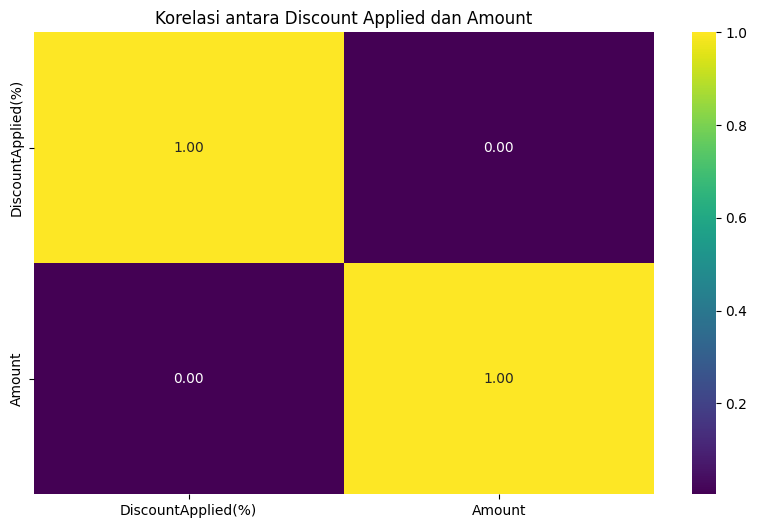

In [69]:
plt.figure(figsize=(10, 6))
sns.heatmap(data=df[['DiscountApplied(%)', 'Amount']].corr(),
            annot=True,
            cmap='viridis',
            fmt='.2f')
plt.title('Korelasi antara Discount Applied dan Amount')
plt.show()

Insight Relationship antara DiscountApplied dan Amount

Nilai korelasi antara DiscountApplied dan Amount sebesar 0.00. Ini menunjukkan tidak ada hubungan linear yang signifikan antara besarnya diskon dan nilai transaksi. Peningkatan atau penurunan diskon tidak berkaitan langsung dengan naik turunnya Amount.

Pada heatmap terlihat angka 1.00 pada diagonal karena variabel dibandingkan dengan dirinya sendiri. Nilai 0.00 pada perpotongan DiscountApplied dan Amount menunjukkan korelasi sangat lemah atau tidak ada hubungan linear. Warna yang tidak pekat pada bagian tersebut menegaskan bahwa diskon tidak menjadi faktor utama yang memengaruhi besar kecilnya transaksi. Ini berarti kemungkinan pelanggan membeli berdasarkan kebutuhan atau jenis produk, bukan semata karena potongan harga.

# **CHECKPOINT 3**

## **Data Preperation**

### **Missing Values**

Pada tahap ini kita akan menangani data yang hilang. Perlu diingat bahwa missing values sendiri jika >= 70% akan dihapus, dan <= 70% akan diimputasi.

Tentu ini bukan menjadi patokan sepenuhnya, kita harus tetap memahami kolom tersebut (tujuannya apa?) dan insight apa yang ingin kita hasilkan pada dataset ini.

In [70]:
pd.DataFrame(df.isna().sum() / len(df) * 100, columns=['Null Ratio %'])

,Null Ratio %
CustomerID,0.0
Age,0.0
Gender,0.0
Category,0.0
ItemPurchased,0.0
Amount,0.0
Season,0.0
PaymentMethod,0.0
ItemRating,0.0
DiscountApplied(%),0.0


Dapat kita lihat dari hasil di atas yang menunjukkan tidak adanya missing values pada dataset tersebut.

### **Inconsistent Values**

Pada tahap ini, kita akan menangani ketidakkonsistenan data & tipe data, yang sudah kita temukan pada tahap verifikasi data sebelumnya.

Dapat kita lihat pada verifikasi kualitas data bagian inconsistent values tidak terdapat ketidakkonsistenan dan tipedata yang perlu dibaiki pada dataset.

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CustomerID          5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Gender              5000 non-null   object 
 3   Category            5000 non-null   object 
 4   ItemPurchased       5000 non-null   object 
 5   Amount              5000 non-null   float64
 6   Season              5000 non-null   object 
 7   PaymentMethod       5000 non-null   object 
 8   ItemRating          5000 non-null   float64
 9   DiscountApplied(%)  5000 non-null   int64  
 10  PreviousPurchases   5000 non-null   int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 429.8+ KB


### **Duplicate Values**

Terlihat pada dataset ini tidak ada duplikasi. Maka hal ini tidak perlu ditangani, namun jika ingin menangani anda dapat mengetikkan

df = df.drop_duplicates()

### **Outliers Values**

Outliers adalah nilai yang jauh berbeda dari nilai lainnya dalam dataset. Nilai Outlier bisa jauh lebih rendah atau lebih tinggi. Outlier bisa terjadi karena berbagai alasan seperti faktor kesalahan maupun kejadian lain yang tidak terduga.

In [72]:
results = []

cols = df.select_dtypes(include=['float64', 'int64'])

for col in cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  percent_outliers = (len(outliers)/len(df))*100
  results.append({'Kolom': col, 'Persentase Outliers': percent_outliers})

# Dataframe dari list hasil
results_df = pd.DataFrame(results)
results_df.set_index('Kolom', inplace=True)
results_df = results_df.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)

# Tampilkan dataframe
display(results_df)

Kolom,Persentase Outliers
CustomerID,0.00
Age,0.00
Amount,10.14
ItemRating,0.18
DiscountApplied(%),0.44
PreviousPurchases,1.16


1. **Amount**

Saya menghapus outliers agar rata rata penjualan lebih stabil dan mewakili kondisi normal. Nilai ekstrem bisa membuat rata rata terlalu tinggi atau terlalu rendah sehingga tidak mencerminkan performa harian yang sebenarnya. Dengan data yang lebih bersih, manajemen dapat menetapkan target, merencanakan stok, dan membuat prediksi dengan lebih akurat.

In [73]:
columns_to_impute = ["Amount"]

for col in columns_to_impute:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Menggunakan .loc[] agar tidak muncul SettingWithCopyWarning
    df.loc[:, col] = df[col].clip(lower=lower_bound, upper=upper_bound)

2. **ItemRating**

Pada kolom ini outlier tidak perlu dihapus karena semua nilai masih berada dalam rentang skala yang valid, yaitu 1 sampai 5 dan setiap pelanggan mempunyai standar penilaian yang berbeda.


In [74]:
df['ItemRating'].value_counts().sort_index()

,count
ItemRating,
1.1,1
1.3,1
1.4,1
1.5,2
1.6,1
1.7,3
1.8,5
1.9,9
2.0,9


3. **DiscountApplied**

Karena persentasenya di bawah 1% tidak terlalu mengganggu analisis secara signifikan. Nilai diskon masih masuk akal dalam konteks promo khusus, cuci gudang, atau kampanye musiman. Menghapusnya justru bisa menghilangkan informasi penting terkait strategi promosi yang berdampak pada penjualan.

4. **Previous Purchases**

kolom ini tetap dibiarkan karena mencerminkan frekuensi pembelian pelanggan secara alami yang bisa bervariasi. Bisa saja terdapat pelanggan yang loyal membeli dengan jumlah yang tinggi dan hal tersebut merupakan hal yang wajar dalam konteks bisnis.

## **Construt Data**

Tahap Construct Data adalah proses kreatif dalam analisis data. Di sini, kita tidak lagi hanya membersihkan data, melainkan membuat sesuatu yang baru dari data yang sudah ada untuk memperkaya analisis.

1. Membuat kolom baru "NetAmount"

Kolom ini digunakan untuk menunjukkan nilai bersih setelah dikurangi dengan diskon. Adapun tujuannya untuk menunjukkan pendapatan nyata yang diterima, membantu analisis efektivitas promo/discount, dan membantu perhitungan profit yang lebih akurat.

In [75]:
df['NetAmount'] = df['Amount'] - (df['Amount'] * df['DiscountApplied(%)'] / 100)

2. Mengecek apakah kolom tersebut sudah ada?

In [76]:
print(df.columns)

Index(['CustomerID', 'Age', 'Gender', 'Category', 'ItemPurchased', 'Amount',
       'Season', 'PaymentMethod', 'ItemRating', 'DiscountApplied(%)',
       'PreviousPurchases', 'NetAmount'],
      dtype='object')


Dapat dilihat kolom baru yang kita buat "NetAmount" sudah terlihat.

## **Data Redaction**

Tahap Data Reduction (Pengurangan Data) bertujuan untuk menyederhanakan dataset Anda tanpa menghilangkan informasi penting. Fokusnya adalah membuang data yang "berisik" (noisy), tidak relevan, atau terlalu detail sehingga proses analisis menjadi lebih cepat dan hasil visualisasinya lebih bersih.

Kita akan menghapus kolom CostumerID karena tidak relevan dengan tujuan analisis dan agar hasil visualisasi yang dihasilkan jauh lebih bersih.

In [77]:
df = df.drop('CustomerID', axis=1)

# **CHECKPOINT 4**

## **Visualization**

### **Comparison**

Visualisasi yang cocok digunakan untuk comparison ialah bar chart dan line chart.

*   Bar Chart digunakan karena memudahkan melihat perbedaan nilai antar kategori.
*   Line Chart digunakan karena garis menunjukkan perubahan nilai dari waktu ke waktu.

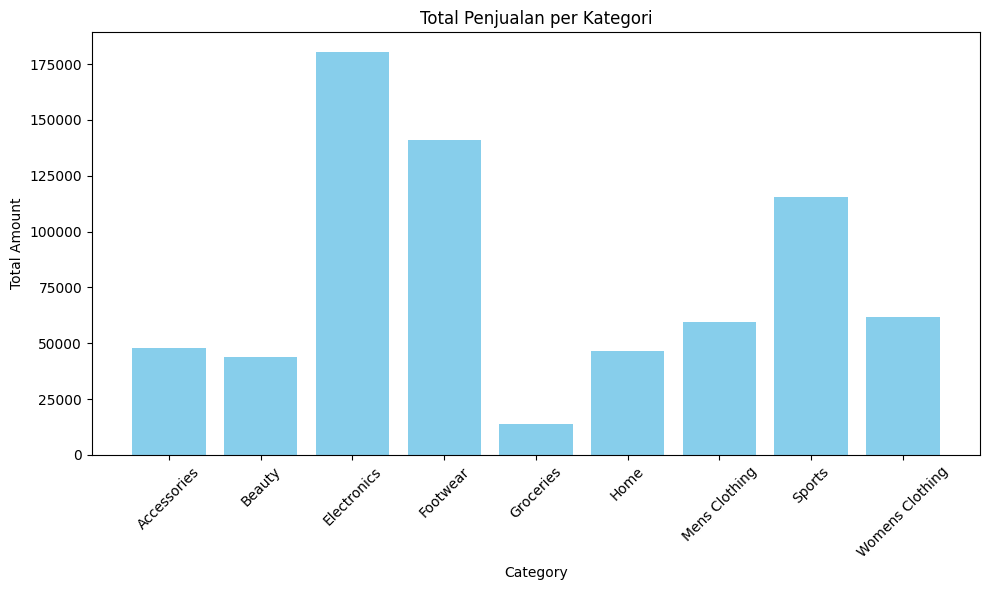

In [78]:
amount_by_category = df.groupby('Category')['Amount'].sum()

plt.figure(figsize=(10, 6))
plt.bar(amount_by_category.index, amount_by_category.values, color='skyblue')
plt.xlabel('Category')
plt.ylabel('Total Amount')
plt.title('Total Penjualan per Kategori')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight**

Kategori Electronics menjadi kategori teratas dalam penjualan, disusul oleh Footwear dan Sports sebagai top 2 dan 3. Sebaliknya, kategori Groceries memiliki nilai yang sangat rendah dibandingkan kategori lainnya.

**Action**

Fokuskan promosi dan stok produk pada kategori Electronics agar penjualan tetap tinggi. Evaluasi kategori Groceries untuk melihat apakah produk masih sesuai dengan kebutuhan pasar

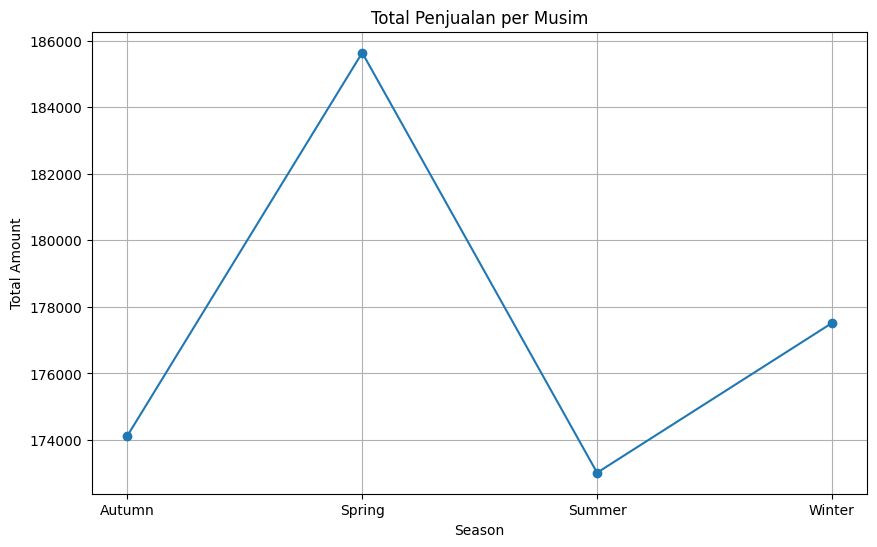

In [79]:
amount_per_season = df.groupby('Season')['Amount'].sum()

plt.figure(figsize=(10,6))
plt.plot(amount_per_season.index, amount_per_season.values, marker='o')
plt.title('Total Penjualan per Musim')
plt.xlabel('Season')
plt.ylabel('Total Amount')
plt.grid(True)
plt.show()

**Insight**

Penjualan dari musim autumn ke spring terjadi kenaikan yang tinggi. Setelah itu penjualan cukup turun jauh pada musim spring ke summer. Kemudian, penjualan mulai naik kembali pada musim winter namun tidak setinggi saat musim spring.

**Action**

Buat promosi khusus pada musim Summer agar penjualan tidak turun terlalu jauh. Gunakan keuntungan dari musim Spring untuk mendukung promosi atau pengembangan produk yang cocok digunakan pada musim panas.

### **Composition**

Visualisasi yang cocok digunakan untuk composition ialah pie chart.

* Pie Chart digunakan karena menunjukkan persentase bagian terhadap total.

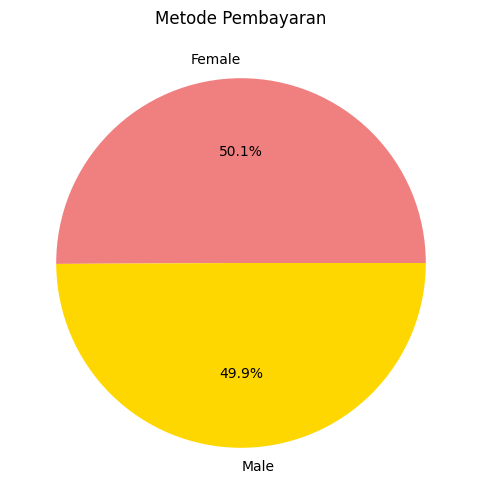

In [80]:
plt.figure(figsize=(10, 6))
plt.pie(df['Gender'].value_counts(), labels=df['Gender'].value_counts().index, autopct='%1.1f%%', colors=['lightcoral', 'gold'])
plt.title('Metode Pembayaran')
plt.show()

**Insight**

Jumlah pelanggan perempuan dan laki laki hampir sama, perempuan sekitar 50.1 persen dan laki laki sekitar 49.9 persen. Ini menunjukkan bahwa produk menarik bagi kedua gender.

**Action**

Gunakan strategi pemasaran yang bisa menjangkau laki laki dan perempuan secara seimbang. Pastikan stok produk juga disesuaikan dengan kebutuhan kedua kelompok pelanggan agar tidak terjadi kelebihan stok pada salah satu segmen.

### **Distribution**

visualisasi yang cocok digunakan untuk distribution ialah histogram dan boxplot.

* Histogram digunakan karena menunjukkan sebaran data dalam beberapa interval nilai.
* BoxPlot digunakan karena menampilkan median, rentang data, dan outlier sehingga distribusi data mudah dianalisis.

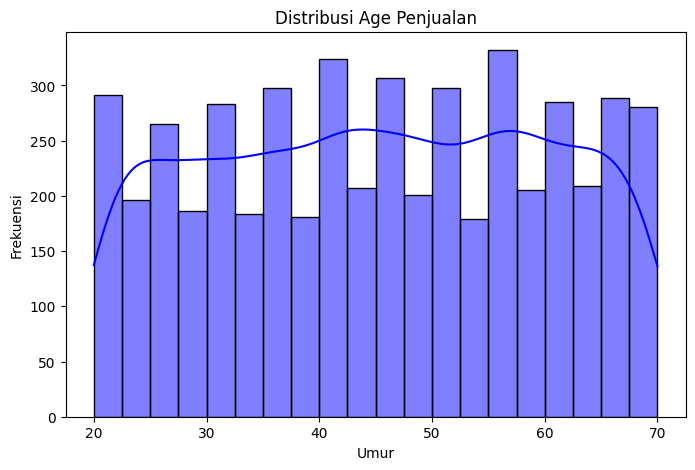

In [81]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], bins=20, kde=True, color='blue')
plt.title('Distribusi Age Penjualan')
plt.xlabel('Umur')
plt.ylabel('Frekuensi')
plt.show()

**Insight**

Visualisasi histogram menunjukkan bahwa distribusi umur pelanggan tersebar cukup merata pada rentang 20 hingga 70 tahun, tanpa adanya satu kelompok umur yang sangat dominan. Namun, terlihat sedikit konsentrasi pada rentang 35 hingga 45 tahun serta 50 hingga 60 tahun, yang menunjukkan bahwa kelompok usia menengah hingga menjelang senior memiliki frekuensi pembelian yang relatif lebih tinggi dibandingkan kelompok usia lainnya. Pola distribusi yang cukup merata ini juga mengindikasikan bahwa produk atau layanan yang dijual memiliki daya tarik yang cukup luas di berbagai kelompok usia pelanggan.

**Action**

Segmentasi pelanggan berdasarkan kelompok usia, kemudian melakukan pendekatan pemasaran yang lebih personal untuk setiap segmen tersebut. Misalnya, pelanggan usia 30 hingga 45 tahun dapat ditargetkan dengan promosi produk yang lebih praktis dan efisien, sementara pelanggan 50 tahun ke atas dapat diberikan program loyalitas atau diskon khusus. Selain itu, analisis lanjutan seperti perbandingan nilai transaksi atau jumlah pembelian per kelompok umur dapat dilakukan untuk mengidentifikasi segmen usia mana yang memberikan kontribusi revenue paling besar.

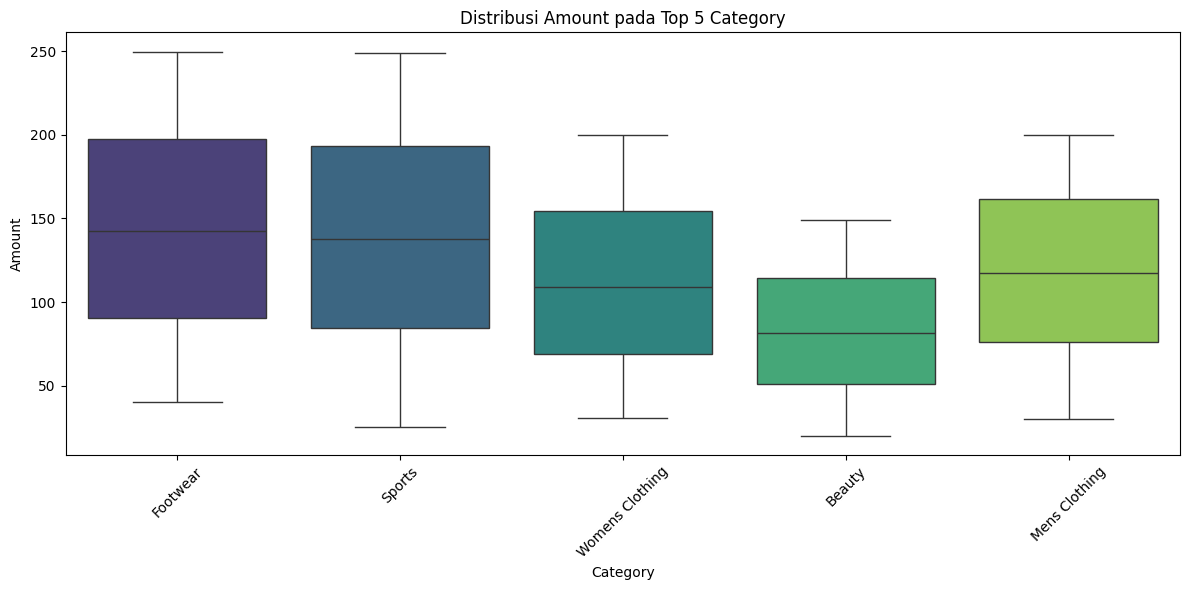

In [82]:
top5kategori = df['Category'].value_counts().head(5).index

df_top5 = df[df['Category'].isin(top5kategori)]

plt.figure(figsize=(12,6))
sns.boxplot(x='Category', y='Amount', data=df_top5, order=top5kategori, palette='viridis', legend=False)

plt.title('Distribusi Amount pada Top 5 Category')
plt.xlabel('Category')
plt.ylabel('Amount')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Insight**

Kategori Footwear dan Sports memiliki nilai transaksi yang cukup tinggi, harga produknya juga memiliki variasi yang cukup banyak. Kategori Beauty memiliki nilai transaksi lebih kecil sehingga pelanggan biasanya membeli produk dengan harga rendah.

**Action**

Tampilkan kategori Footwear dan Sports sebagai produk utama untuk meningkatkan nilai pembelian pelanggan. Pada kategori Beauty gunakan strategi paket produk atau bundling agar pelanggan membeli lebih dari satu produk dalam satu transaksi.

### **Relationship**

Visualisasi yang cocok digunakan untuk relationship ialah scatterplot, heatmap, dan bubble chart.

* ScatterPlot digunakan karena menunjukkan hubungan antara dua variabel melalui posisi titik.
* Heatmap digunakan karena menunjukkan kekuatan hubungan antar variabel melalui perbedaan warna.
* Bubble Chart digunakan karena dapat menampilkan hubungan tiga variabel sekaligus melalui ukuran gelembung.

Akan tetapi, pada visualisasi tidak memakai scatterplot dan bubble chart karena hasil visualisasi berupa garis lurus ke atas jadi visualisasi tersebut kurang tepat digunakan. Alasannya, nilai pada salah satu variabel memiliki variasi yang sangat sedikit. Banyak data memiliki nilai yang sama sehingga titik menumpuk pada posisi yang sama. Pola hubungan antar variabel menjadi sulit dianalisis.

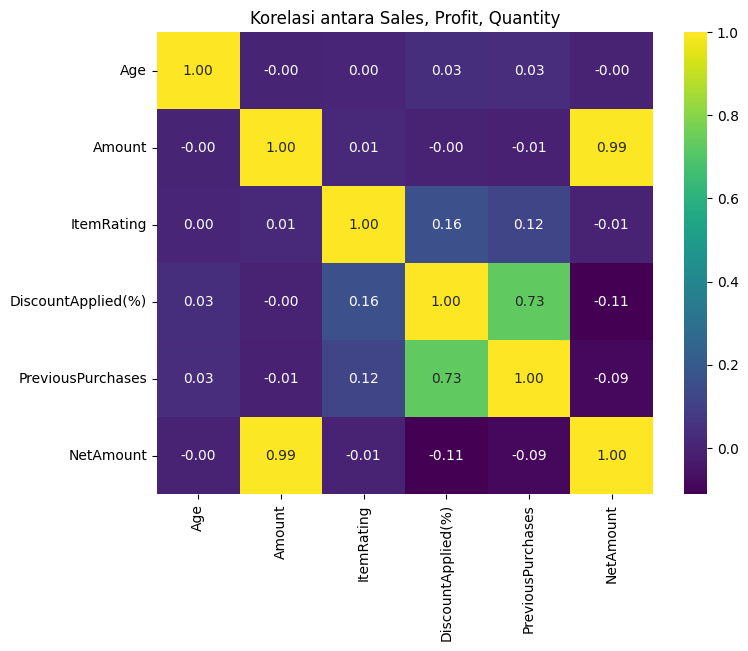

In [83]:
plt.figure(figsize=(8, 6))
sns.heatmap(data=df.corr(numeric_only=True),
            annot=True,
            cmap='viridis',
            fmt='.2f')
plt.title('Korelasi antara Sales, Profit, Quantity')
plt.show()

**Insight**

**Action**

Heatmap korelasi menunjukkan bahwa terdapat hubungan yang sangat kuat antara Amount dan NetAmount (0.99), yang mengindikasikan bahwa kedua variabel tersebut hampir memiliki pola yang sama dalam menggambarkan nilai transaksi pelanggan. Selain itu, terdapat hubungan yang cukup kuat antara DiscountApplied dan PreviousPurchases (0.73) yang menunjukkan bahwa pelanggan dengan riwayat pembelian lebih banyak cenderung menerima diskon lebih besar. Sementara itu, variabel lain seperti Age dan ItemRating memiliki korelasi yang sangat rendah dengan nilai transaksi, yang berarti faktor tersebut tidak memiliki pengaruh signifikan terhadap besarnya pembelian pelanggan dalam dataset ini.


**Action**

Berdasarkan hubungan antar variabel tersebut, perusahaan dapat mengoptimalkan strategi program loyalitas berbasis riwayat pembelian, misalnya dengan memberikan diskon khusus kepada pelanggan yang telah melakukan pembelian berulang untuk meningkatkan retensi pelanggan. Selain itu, karena Amount dan NetAmount memiliki korelasi yang hampir sempurna, analisis atau model prediksi selanjutnya sebaiknya hanya menggunakan salah satu variabel untuk menghindari redundansi data. Perusahaan juga dapat melakukan analisis lanjutan seperti pengaruh diskon terhadap peningkatan pembelian atau nilai transaksi, sehingga kebijakan diskon yang diterapkan dapat lebih efektif dalam meningkatkan pendapatan.

# **Menyimpan Dataset**

In [84]:
df.to_csv('Retail Store Sales [clean].csv', index=False)